In [1]:
"""
FINUFFT
Here I provide a first try at getting FINUFFT to work. The first step is to install finufft on Tycho,
as far as I recall I simply did

pip install finufft
"""

import finufft
import paicos as pa
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%matplotlib widget

# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
snap = pa.Snapshot(pa.data_dir, 247)
center = snap.Cat.Group['GroupPos'][0]
R200c = snap.Cat.Group['Group_R_Crit200'][0]
r_max = 1.0 * R200c
# index = pa.util.get_index_of_radial_range(snap['0_Coordinates'], center, 0., r_max)

widths = np.array([2e3, 2e3, 2e3], dtype=float)
index = pa.util.get_index_of_cubic_region(snap['0_Coordinates'], center, widths, snap.box)
snap = snap.select(index, parttype=0)



In [2]:
def power_spectrum_finufft1d(kvec, vhat):
    # vhat and kvec have the same shape: (N,)
    # kvec is the absolute value of the 2d/3d wavevector
    N = vhat.shape[0]
    kmax = int(np.max(kvec) + 0.5)
    kmin = int(np.min(kvec))
    k1d = np.arange(kmin, kmax+1)
    powerspectr = np.zeros(k1d.shape)
    for i in range(len(powerspectr)):
        indices = np.argwhere(kvec.astype('int')==k1d[i])
        if (indices.size != 0):
            powerspectr[i] = np.sum((vhat[indices]*np.conj(vhat[indices])).real)
    return powerspectr, k1d

In [4]:
def power_spectrum_numpyfft1d(kvec, vhat):
    # vhat and kvec have the same shape: (N,N,N)
    # kvec is the absolute value of the 2d/3d wavevector
    N = vhat.shape[0]
    ndim = len(vhat.shape)
    kmax = int(np.sqrt(ndim)*(N//2+1) + 0.5)
    kmin = 0
    k1d = np.arange(kmin, kmax+1)
    powerspectr = np.zeros(k1d.shape)
    for i in range(len(powerspectr)):
        indices = np.argwhere(kvec.astype('int')==k1d[i])
        if (indices.size != 0):
            powerspectr[i] = np.sum((vhat[indices[:,0],indices[:,1],indices[:,2]] \
                                     *np.conj(vhat[indices[:,0],indices[:,1],indices[:,2]])).real)/((N*N)**ndim)
            # powerspectr[i] = np.sum((vhat[indices]*np.conj(vhat[indices])).real)
    return powerspectr, k1d

In [5]:
def nearest_grid_point_deposit(ngpField, particleCoords, particleField):
    # ngpField is (n1d,n1d,n1d) complex vector
    # but with periodic boundary conditions only n1d-1 
    # elements in all directions are needed
    # particleCoords has shape (N,3)
    # particleField has shape (N,)
    
    N = np.shape(particleField)[0]
    n1d = np.shape(ngpField)[0]
    Deltax = 2.0*np.pi/(n1d-1)
    Deltay = 2.0*np.pi/(n1d-1)
    Deltaz = 2.0*np.pi/(n1d-1)

    x = particleCoords[:,0]
    y = particleCoords[:,1]
    z = particleCoords[:,2]
    
    # idx_x, idx_y, idx_z are vectors of indices
    # such that particle belongs to cell
    # [x(idx_x)-1/2 Deltax, x(idx_x)+1/2 Deltax]
    # i.e. the closest grid point

    idx_x = ((x + 0.5*Deltax)//Deltax).astype('int')%(n1d-1)
    idx_y = ((y + 0.5*Deltay)//Deltay).astype('int')%(n1d-1)
    idx_z = ((z + 0.5*Deltaz)//Deltaz).astype('int')%(n1d-1)

    for i in range(n1d-1):
        for j in range(n1d-1):
            for k in range(n1d-1):
                particles_belonging_to_cell = particleField[(idx_x==i)*(idx_y==j)*(idx_z==k)]
                if (particles_belonging_to_cell.size != 0):
                    ngpField[i,j,k] = np.mean(particleField[(idx_x==i)*(idx_y==j)*(idx_z==k)].real) + 0.0j
    
    ngpField[:,:,-1] = ngpField[:,:,0]
    ngpField[:,-1,:] = ngpField[:,0,:]
    ngpField[-1,:,:] = ngpField[0,:,:]
    


def cic_deposit(cicField, particleCoords, particleField):
    # method implemented from http://background.uchicago.edu/~whu/Courses/Ast321_11/pm.pdf
    # slide 13
    # cicField is (n1d,n1d,n1d) complex vector
    # but with periodic boundary conditions only n1d-1 
    # elements in all directions are needed
    # particleCoords has shape (N,3)
    # particleField has shape (N,)
    N = np.shape(particleField)[0]
    n1d = np.shape(cicField)[0]
    Deltax = 2.0*np.pi/(n1d-1)
    Deltay = 2.0*np.pi/(n1d-1)
    Deltaz = 2.0*np.pi/(n1d-1)

    weights = np.zeros(cicField.shape)
    
    for n in range(N):
        xp, yp, zp = particleCoords[n]
        # idx_x, idx_y, idx_z is are the indices of coords
        # such that particle belongs to cell
        # [x(idx_x), x(idx_x+1)]
        idx_x = int((xp)//Deltax)
        idx_y = int((yp)//Deltay)
        idx_z = int((zp)//Deltaz)
        # call xc = x(idx_x) and so on
        xc = (0.0 + idx_x * Deltax)
        yc = (0.0 + idx_y * Deltay)
        zc = (0.0 + idx_z * Deltaz)

        d_x = (xp - xc)/Deltax
        d_y = (yp - yc)/Deltay
        d_z = (zp - zc)/Deltaz
        
        idx_x = idx_x%(n1d-1)
        idx_y = idx_y%(n1d-1)
        idx_z = idx_z%(n1d-1)

        try:
            assert ((d_x >= 0.0) and (d_x < 1.0))
        except:
            print(d_x)
            print(idx_x, idx_y, idx_z)
            

        t_x = 1.0 - d_x
        t_y = 1.0 - d_y
        t_z = 1.0 - d_z
        
        cicField[idx_x, idx_y, idx_z] += particleField[n]*t_x*t_y*t_z
        cicField[idx_x, (idx_y+1)%(n1d-1), idx_z] += particleField[n]*t_x*d_y*t_z
        cicField[idx_x, idx_y, (idx_z+1)%(n1d-1)] += particleField[n]*t_x*t_y*d_z
        cicField[idx_x, (idx_y+1)%(n1d-1), (idx_z+1)%(n1d-1)] += particleField[n]*t_x*d_y*d_z
        cicField[(idx_x+1)%(n1d-1), idx_y, idx_z] += particleField[n]*d_x*t_y*t_z
        cicField[(idx_x+1)%(n1d-1), (idx_y+1)%(n1d-1), idx_z] += particleField[n]*d_x*d_y*t_z
        cicField[(idx_x+1)%(n1d-1), idx_y, (idx_z+1)%(n1d-1)] += particleField[n]*d_x*t_y*d_z
        cicField[(idx_x+1)%(n1d-1), (idx_y+1)%(n1d-1), (idx_z+1)%(n1d-1)] += particleField[n]*d_x*d_y*d_z

        # To do a weighted average
        # I have to divide by the sum of the weights 
        weights[idx_x, idx_y, idx_z] += t_x*t_y*t_z
        weights[idx_x, (idx_y+1)%(n1d-1), idx_z] += t_x*d_y*t_z
        weights[idx_x, idx_y, (idx_z+1)%(n1d-1)] += t_x*t_y*d_z
        weights[idx_x, (idx_y+1)%(n1d-1), (idx_z+1)%(n1d-1)] += t_x*d_y*d_z
        weights[(idx_x+1)%(n1d-1), idx_y, idx_z] += d_x*t_y*t_z
        weights[(idx_x+1)%(n1d-1), (idx_y+1)%(n1d-1), idx_z] += d_x*d_y*t_z
        weights[(idx_x+1)%(n1d-1), idx_y, (idx_z+1)%(n1d-1)] += d_x*t_y*d_z
        weights[(idx_x+1)%(n1d-1), (idx_y+1)%(n1d-1), (idx_z+1)%(n1d-1)] += d_x*d_y*d_z

    cicField[cicField.real!=0.0] /= weights[cicField.real!=0.0]
    cicField[:,:,-1] = cicField[:,:,0]
    cicField[:,-1,:] = cicField[:,0,:]
    cicField[-1,:,:] = cicField[0,:,:]

        

In [7]:
def exp_profile(x, y, z, x0, y0, z0, sigma):
    r2 = (x - x0)**2 + (y - y0)**2 + (z - z0)**2
    return np.exp(-r2/sigma**2)

In [8]:
N = snap['0_Coordinates'].shape[0]

x = 2 * np.pi * (snap['0_Coordinates'][:, 0].value - ( center[0].value - widths[0]/2. )) / widths[0]
y = 2 * np.pi * (snap['0_Coordinates'][:, 1].value - ( center[1].value - widths[1]/2. )) / widths[1]
z = 2 * np.pi * (snap['0_Coordinates'][:, 2].value - ( center[2].value - widths[2]/2. )) / widths[2]


c = np.zeros((N,), dtype='complex128')
coeff = []
for i in range(1,10):
    rnd_amplitude = 0.1
    rnd_phase     = np.random.uniform(size=1)*2.0*np.pi
    rnd_phase = 0.0
    c +=  rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*x*i + rnd_phase).real + 0.0j \
        + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*x*i + rnd_phase).real 
    coeff.append(rnd_amplitude*(1/(1 + (i-4)**2)))
    

grid_size = int(np.cbrt(N))

# # desired number of Fourier modes
kx = np.arange(-(grid_size//2+1), grid_size//2+1)*1.0
ky = np.arange(-(grid_size//2+1), grid_size//2+1)*1.0
kz = np.arange(-(grid_size//2+1), grid_size//2+1)*1.0

KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')

kx = KX.flatten()
ky = KY.flatten()
kz = KZ.flatten()

# calculate the NUFFT
vhat = finufft.nufft3d3(x, y, z, c, kx, ky, kz)
kvec = np.sqrt(kx**2 + ky**2 + kz**2)

In [9]:
#### NOTE this is the number of points that the 
#### regular grid will have in all directions
n1d = 4*int(np.cbrt(N))
# n1d = 20

#################################
# this is just a sanity check
# it "deposits" the field at the actual uniform grid-point locations
# (it just evaluates it)
# (useful to test the numpy fft)

x_uniform = 2.0*np.pi*np.linspace(0,1,n1d)
y_uniform = 2.0*np.pi*np.linspace(0,1,n1d)
z_uniform = 2.0*np.pi*np.linspace(0,1,n1d)

X_uniform, Y_uniform, Z_uniform = np.meshgrid(x_uniform, y_uniform, z_uniform, indexing='ij')

c_eval = np.zeros((n1d,n1d,n1d), dtype='complex128')
for i in range(1,10):
    rnd_amplitude = 0.1
    rnd_phase     = np.random.uniform(size=1)*2.0*np.pi
    rnd_phase = 0.0
    c_eval +=  rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*X_uniform*i + rnd_phase).real + 0.0j \
        + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*X_uniform*i + rnd_phase).real

########################

## this is nearest grid point deposit routine
c_ngp = np.zeros((n1d,n1d,n1d), dtype='complex128')
nearest_grid_point_deposit(c_ngp, np.stack((x,y,z)).T, c)

## this is the cloud in cell deposit routine
c_cic = np.zeros((n1d,n1d,n1d), dtype='complex128')
cic_deposit(c_cic, np.stack((x,y,z)).T, c)

##########################################
## choose which deposit routine to use
## on a uniform grid

### 1. simply evaluate the actual function
vhat_eval = np.fft.fftn(c_eval)
### 2. nearest grid point deposit
vhat_ngp = np.fft.fftn(c_ngp)
### 3. cloud in cell deposit
vhat_cic = np.fft.fftn(c_cic)

##########################################

kx_uniform = np.fft.fftfreq(n1d, d=1.0/n1d)
ky_uniform = np.fft.fftfreq(n1d, d=1.0/n1d)
kz_uniform = np.fft.fftfreq(n1d, d=1.0/n1d)

KX_uniform, KY_uniform, KZ_uniform = np.meshgrid(kx_uniform, ky_uniform, kz_uniform, indexing='ij')

k_uniform = np.sqrt(KX_uniform**2 + KY_uniform**2 + KZ_uniform**2)

In [10]:
powerspectr, k1d = power_spectrum_finufft1d(kvec, vhat)
powerspectr /= N*N

In [11]:
powerspectr_eval, k1d_uniform = power_spectrum_numpyfft1d(k_uniform, vhat_eval)

In [12]:
powerspectr_ngp, k1d_uniform = power_spectrum_numpyfft1d(k_uniform, vhat_ngp)

In [13]:
powerspectr_cic, k1d_uniform = power_spectrum_numpyfft1d(k_uniform, vhat_cic)

/groups/astro/lperrone/.local/lib/python3.10/site-packages/ipympl/backend_nbagg.py:336: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


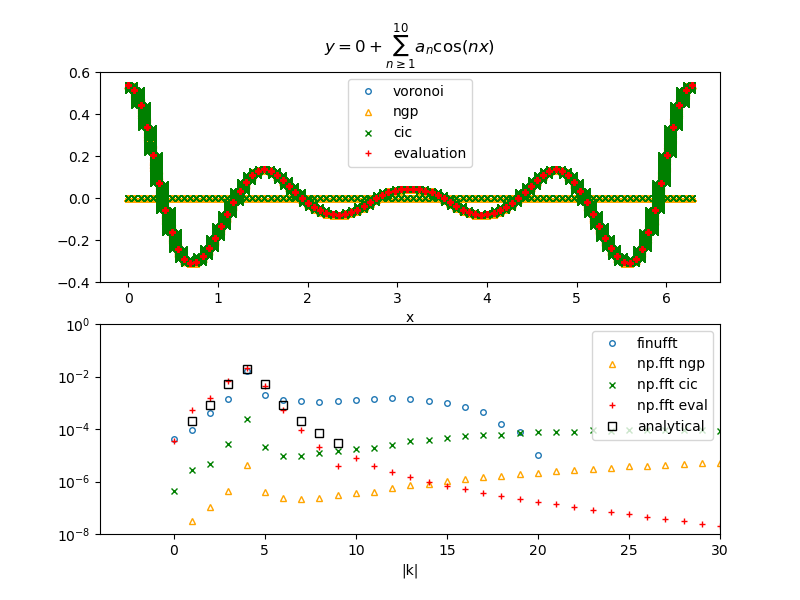

In [14]:
fig, ax = plt.subplots(2,1,figsize=(8,6))

ax[0].plot(x, c.real, ls='', marker='o', markerfacecolor='none', markersize=4, label='voronoi')
ax[0].plot(X_uniform.flatten(), c_ngp.flatten().real, ls='', marker='^', color='orange', markerfacecolor='none', markersize=4, label='ngp')
ax[0].plot(X_uniform.flatten(), c_cic.flatten().real, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='cic')
ax[0].plot(X_uniform.flatten(), c_eval.flatten().real, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='evaluation')

ax[0].set_xlabel('x')
ax[0].legend()

ax[1].plot(k1d, powerspectr, ls='', marker='o', markerfacecolor='none', markersize=4, label='finufft')
ax[1].plot(k1d_uniform, powerspectr_ngp, ls='', marker='^', color='orange', markerfacecolor='none', markersize=4, label='np.fft ngp')
ax[1].plot(k1d_uniform, powerspectr_cic, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='np.fft cic')
ax[1].plot(k1d_uniform, powerspectr_eval, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='np.fft eval')
ax[1].plot(np.arange(1,10), 2.0*np.array(coeff)**2, ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
ax[1].set_xlabel('|k|')
ax[1].set_yscale('log')

ax[1].legend()

ax[0].set_title(r'$y = 0 + \sum_{n \geq 1}^{10} a_n \cos (n x) $')


ax[0].set_ylim(ymin=-0.4, ymax=0.6)
ax[1].set_ylim(ymin=1e-8, ymax=1e0)
ax[1].set_xlim(xmax=30)


plt.show()




In [19]:
1./np.max((snap['0_Diameters'].value ) / widths[0])

7.986659626083847

In [18]:
1./np.min((snap['0_Diameters'].value ) / widths[0])

154.51453021022988

In [22]:
####### same as before but with +1.0

c = np.ones((N,), dtype='complex128')

for i in range(1,10):
    rnd_amplitude = 0.1
    rnd_phase     = np.random.uniform(size=1)*2.0*np.pi
    rnd_phase = 0.0
    c +=  rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*x*i + rnd_phase).real + 0.0j \
        + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*x*i + rnd_phase).real 
 

# calculate the NUFFT
vhat = finufft.nufft3d3(x, y, z, c, kx, ky, kz)
kvec = np.sqrt(kx**2 + ky**2 + kz**2)

c_eval = np.ones((n1d,n1d,n1d), dtype='complex128')
for i in range(1,10):
    rnd_amplitude = 0.1
    rnd_phase     = np.random.uniform(size=1)*2.0*np.pi
    rnd_phase = 0.0
    c_eval +=  rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*X_uniform*i + rnd_phase).real + 0.0j \
        + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*X_uniform*i + rnd_phase).real


## this is nearest grid point deposit routine
c_ngp = np.zeros((n1d,n1d,n1d), dtype='complex128')
nearest_grid_point_deposit(c_ngp, np.stack((x,y,z)).T, c)

## this is the cloud in cell deposit routine
c_cic = np.zeros((n1d,n1d,n1d), dtype='complex128')
cic_deposit(c_cic, np.stack((x,y,z)).T, c)

c_ngp[c_ngp==0.0 + 0.0j] = 1.0+0.0j
c_cic[c_cic==0.0 + 0.0j] = 1.0+0.0j
##########################################
## choose which deposit routine to use
## on a uniform grid

### 1. simply evaluate the actual function (no need)
vhat_eval = np.fft.fftn(c_eval)
### 2. nearest grid point deposit
vhat_ngp = np.fft.fftn(c_ngp)
### 3. cloud in cell deposit
vhat_cic = np.fft.fftn(c_cic)

##########################################

powerspectr, k1d = power_spectrum_finufft1d(kvec, vhat)
powerspectr /= N*N

powerspectr_eval, k1d_uniform = power_spectrum_numpyfft1d(k_uniform, vhat_eval)

powerspectr_ngp, k1d_uniform = power_spectrum_numpyfft1d(k_uniform, vhat_ngp)

powerspectr_cic, k1d_uniform = power_spectrum_numpyfft1d(k_uniform, vhat_cic)

/groups/astro/lperrone/.local/lib/python3.10/site-packages/ipympl/backend_nbagg.py:336: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


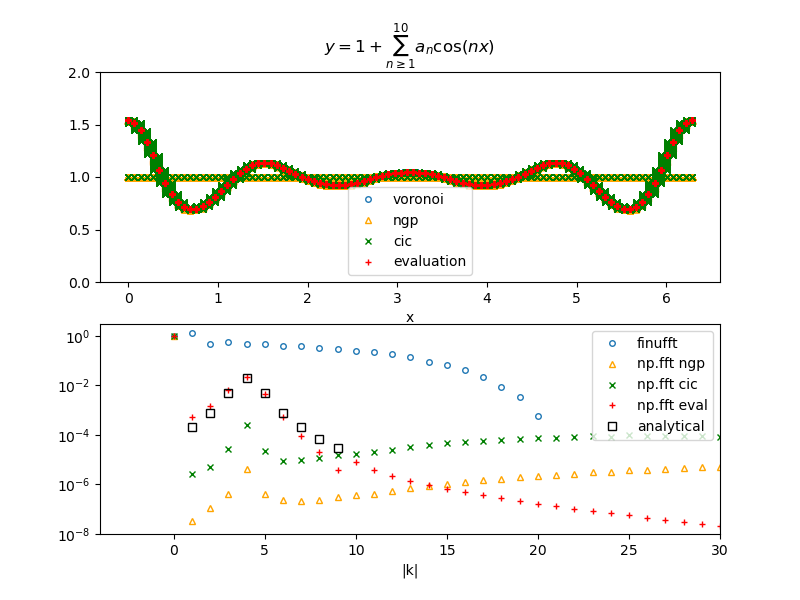

In [23]:
fig, ax = plt.subplots(2,1,figsize=(8,6))


ax[0].plot(x, c.real, ls='', marker='o', markerfacecolor='none', markersize=4, label='voronoi')
ax[0].plot(X_uniform.flatten(), c_ngp.flatten().real, ls='', marker='^', color='orange', markerfacecolor='none', markersize=4, label='ngp')
ax[0].plot(X_uniform.flatten(), c_cic.flatten().real, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='cic')
ax[0].plot(X_uniform.flatten(), c_eval.flatten().real, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='evaluation')

ax[0].set_xlabel('x')
ax[0].legend()

ax[1].plot(k1d, powerspectr, ls='', marker='o', markerfacecolor='none', markersize=4, label='finufft')
ax[1].plot(k1d_uniform, powerspectr_ngp, ls='', marker='^', color='orange', markerfacecolor='none', markersize=4, label='np.fft ngp')
ax[1].plot(k1d_uniform, powerspectr_cic, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='np.fft cic')
ax[1].plot(k1d_uniform, powerspectr_eval, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='np.fft eval')
ax[1].plot(np.arange(1,10), 2.0*np.array(coeff)**2, ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
ax[1].set_xlabel('|k|')
ax[1].set_yscale('log')

ax[1].legend()

ax[0].set_title(r'$y = 1 + \sum_{n \geq 1}^{10} a_n \cos (n x) $')

ax[0].set_ylim(ymin=-0.0, ymax=2.)
ax[1].set_ylim(ymin=1e-8, ymax=3e0)
ax[1].set_xlim(xmax=30)

plt.show()


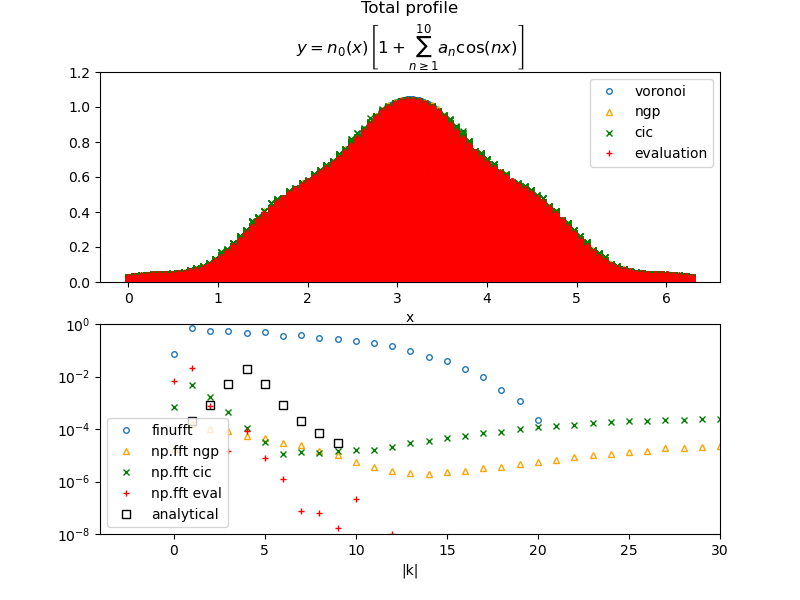

In [24]:
####### same as before but with background profile

c = np.zeros((N,), dtype='complex128')
c0 = exp_profile(x, y, z, np.pi, np.pi, np.pi, np.pi/2.) + 0.0j
c += c0

for i in range(1,10):
    rnd_amplitude = 0.1
    rnd_phase     = np.random.uniform(size=1)*2.0*np.pi
    rnd_phase = 0.0
    c +=  c0*(rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*x*i + rnd_phase).real + 0.0j \
        + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*x*i + rnd_phase).real )


c_eval = np.zeros((n1d,n1d,n1d), dtype='complex128')
c_eval0 = exp_profile(X_uniform, Y_uniform, Z_uniform, np.pi, np.pi, np.pi, np.pi/2.) + 0.0j
c_eval += c_eval0
for i in range(1,10):
    rnd_amplitude = 0.1
    rnd_phase     = np.random.uniform(size=1)*2.0*np.pi
    rnd_phase = 0.0
    c_eval +=  c_eval0*(rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*X_uniform*i + rnd_phase).real + 0.0j \
        + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*X_uniform*i + rnd_phase).real)



# calculate the NUFFT
vhat = finufft.nufft3d3(x, y, z, c, kx, ky, kz)
kvec = np.sqrt(kx**2 + ky**2 + kz**2)

## this is nearest grid point deposit routine
c_ngp = np.zeros((n1d,n1d,n1d), dtype='complex128')
nearest_grid_point_deposit(c_ngp, np.stack((x,y,z)).T, c)

## this is the cloud in cell deposit routine
c_cic = np.zeros((n1d,n1d,n1d), dtype='complex128')
cic_deposit(c_cic, np.stack((x,y,z)).T, c)


##########################################
## choose which deposit routine to use
## on a uniform grid

### 1. simply evaluate the actual function (no need)
vhat_eval = np.fft.fftn(c_eval)
### 2. nearest grid point deposit
vhat_ngp = np.fft.fftn(c_ngp)
### 3. cloud in cell deposit
vhat_cic = np.fft.fftn(c_cic)

##########################################

powerspectr, k1d = power_spectrum_finufft1d(kvec, vhat)
powerspectr /= N*N

powerspectr_eval, k1d_uniform = power_spectrum_numpyfft1d(k_uniform, vhat_eval)

powerspectr_ngp, k1d_uniform = power_spectrum_numpyfft1d(k_uniform, vhat_ngp)

powerspectr_cic, k1d_uniform = power_spectrum_numpyfft1d(k_uniform, vhat_cic)

fig, ax = plt.subplots(2,1,figsize=(8,6))


ax[0].plot(x, c.real, ls='', marker='o', markerfacecolor='none', markersize=4, label='voronoi')
ax[0].plot(X_uniform.flatten(), c_ngp.flatten().real, ls='', marker='^', color='orange', markerfacecolor='none', markersize=4, label='ngp')
ax[0].plot(X_uniform.flatten(), c_cic.flatten().real, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='cic')
ax[0].plot(X_uniform.flatten(), c_eval.flatten().real, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='evaluation')

ax[0].set_xlabel('x')
ax[0].legend()

ax[1].plot(k1d, powerspectr, ls='', marker='o', markerfacecolor='none', markersize=4, label='finufft')
ax[1].plot(k1d_uniform, powerspectr_ngp, ls='', marker='^', color='orange', markerfacecolor='none', markersize=4, label='np.fft ngp')
ax[1].plot(k1d_uniform, powerspectr_cic, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='np.fft cic')
ax[1].plot(k1d_uniform, powerspectr_eval, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='np.fft eval')
ax[1].plot(np.arange(1,10), 2.0*np.array(coeff)**2, ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
ax[1].set_xlabel('|k|')
ax[1].set_yscale('log')

ax[1].legend()

ax[0].set_title('Total profile'+'\n'+r'$y = n_0 (x) \left[ 1 + \sum_{n \geq 1}^{10} a_n \cos (n x) \right]$')

ax[0].set_ylim(ymin=-0.0, ymax=1.2)
ax[1].set_ylim(ymin=1e-8, ymax=1e0)
ax[1].set_xlim(xmax=30)

plt.show()
